> **Copie de comparaison.** Ce notebook est une copie de
> `03_text_to_sql_operations.ipynb`, avec une seule différence : la section
> 5 utilise ici le `SQL_PROMPT` court (celui testé un temps dans
> `app_sql.py`) plutôt que le prompt long mesuré dans le notebook
> d'origine. Objectif : mesurer si la réduction du prompt coûte de
> l'accuracy, et de combien, avant de décider s'il vaut le coup de
> l'adopter pour de vrai. Rien d'autre n'a changé.

# 03 : Assistant GenAI sur les données opérationnelles - text-to-SQL

**Entrée** : base `data/operations.sqlite` (4 tables, générées par `02_generation_donnees.ipynb`)
**LLM** : local via Ollama (llama3.2), configurable (OpenAI possible)
**Prérequis** : application Ollama en marche, `02_generation_donnees.ipynb` déjà exécuté

---

### Objectif

Le notebook `01_retail_operations_rag.ipynb` répond aux questions de procédure
("quel est le délai de retour d'un article soldé ?") en interrogeant les guides
opérationnels. Ce notebook répond à une deuxième catégorie de questions, celle
qui porte sur les données plutôt que sur la doctrine : combien de commandes sont
en retard, quel motif de retour revient le plus souvent, quel est le délai
moyen de remboursement. Un conseiller ou un responsable opérations pose la
question en français, sans écrire de SQL.

Deux questions guident le notebook :

1. **Les données générées reproduisent-elles les règles écrites dans les guides ?**
   Avant d'interroger quoi que ce soit avec un modèle de langage, la partie
   exploratoire vérifie que les délais de retour (30 jours standard, 14 jours
   soldé) et les délais de remboursement (carte bancaire plus lent que carte
   cadeau) se retrouvent bien dans les chiffres.
2. **Le text-to-SQL tient-il quand la question exige une jointure ?**
   C'est précisément ce qui est mesuré dans la partie évaluation, en
   comparant les questions à une seule table à celles qui en croisent
   plusieurs.

### Les quatre tables

| Table | Colonne | Contenu |
|---|---|---|
| `magasins` | `magasin_id` | identifiant du magasin |
| | `nom` | nom du magasin |
| | `ville` | ville |
| `commandes` | `commande_id` | identifiant de la commande |
| | `magasin_id` | magasin (clé étrangère vers `magasins`) |
| | `canal` | `magasin`, `en ligne - livraison` ou `en ligne - click&collect` |
| | `date_commande` | date de la commande |
| | `type_article` | `standard` ou `soldé` |
| | `moyen_paiement` | `carte bancaire` ou `carte cadeau` |
| | `montant` | montant en euros |
| | `statut` | `en cours`, `livrée` ou `retournée` |
| | `delai_traitement_jours` | délai réel de livraison (vide si `en cours`) |
| | `delai_sla_jours` | délai promis selon le canal |
| | `en_retard` | 1 si en retard, vide si `en cours` ou canal `magasin` |
| `retours` | `retour_id` | identifiant du retour |
| | `commande_id` | commande concernée (clé étrangère vers `commandes`) |
| | `date_retour` | date du retour |
| | `motif` | ex. "taille inadaptée", "article défectueux" |
| | `delai_traitement_jours` | délai de traitement du retour par le magasin |
| | `dans_delai` | 1 si le retour respecte le délai contractuel |
| `remboursements` | `remboursement_id` | identifiant du remboursement |
| | `retour_id` | retour concerné (clé étrangère vers `retours`) |
| | `moyen_paiement` | `carte bancaire` ou `carte cadeau` |
| | `montant` | montant remboursé |
| | `date_remboursement` | date du remboursement |
| | `delai_jours` | délai entre le retour et le remboursement |

### Plan

1. Chargement des données
2. Qualité des données
3. Analyse univariée
4. Analyse bivariée
5. Garde-fous et assistant text-to-SQL
6. Tests des garde-fous
7. Démonstration
8. Évaluation du text-to-SQL
9. Synthèse et limites

# 1. Chargement des données

In [1]:
import os, re, sqlite3, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd().parent if (Path.cwd().parent / "data").exists() else Path.cwd()
DB_PATH = ROOT / "data" / "operations.sqlite"

con = sqlite3.connect(DB_PATH)
magasins = pd.read_sql("SELECT * FROM magasins", con)
commandes = pd.read_sql("SELECT * FROM commandes", con)
retours = pd.read_sql("SELECT * FROM retours", con)
remboursements = pd.read_sql("SELECT * FROM remboursements", con)

sns.set_theme(style="whitegrid")
for nom, df in [("magasins", magasins), ("commandes", commandes), ("retours", retours), ("remboursements", remboursements)]:
    print(f"{nom:15s} {len(df):>6,} lignes  |  colonnes : {list(df.columns)}")

magasins             8 lignes  |  colonnes : ['magasin_id', 'nom', 'ville']
commandes        6,024 lignes  |  colonnes : ['commande_id', 'magasin_id', 'canal', 'date_commande', 'type_article', 'moyen_paiement', 'montant', 'statut', 'delai_traitement_jours', 'delai_sla_jours', 'en_retard']
retours          1,080 lignes  |  colonnes : ['retour_id', 'commande_id', 'date_retour', 'motif', 'delai_traitement_jours', 'dans_delai']
remboursements     830 lignes  |  colonnes : ['remboursement_id', 'retour_id', 'moyen_paiement', 'montant', 'date_remboursement', 'delai_jours']


Quatre tables, générées par `02_generation_donnees.ipynb` à partir des règles
écrites dans les guides opérationnels (`data/*.md`) : délais de retour,
délais de remboursement selon le moyen de paiement, motifs réservés aux
commandes en ligne. Rien ici n'est mesuré sur de vraies commandes Maison
Kurt, qui est une enseigne fictive.

In [2]:
display(magasins.head(3))
display(commandes.head(3))
display(retours.head(3))
display(remboursements.head(3))

,magasin_id,nom,ville
0,1,Maison Kurt Paris Haussmann,Paris
1,2,Maison Kurt Lyon Part-Dieu,Lyon
2,3,Maison Kurt Marseille Prado,Marseille


,commande_id,magasin_id,canal,date_commande,type_article,moyen_paiement,montant,statut,delai_traitement_jours,delai_sla_jours,en_retard
0,1,1,en ligne - livraison,2025-07-10,soldé,carte bancaire,20.83,retournée,3.0,5,0.0
1,2,7,en ligne - livraison,2025-07-04,standard,carte bancaire,43.85,livrée,2.0,5,0.0
2,3,6,magasin,2025-05-21,standard,carte bancaire,40.14,livrée,0.0,0,NaN


,retour_id,commande_id,date_retour,motif,delai_traitement_jours,dans_delai
0,1,1,2025-07-29,taille inadaptée,4,0
1,2,10,2025-03-30,taille inadaptée,3,0
2,3,14,2025-05-12,changement d'avis,1,0


,remboursement_id,retour_id,moyen_paiement,montant,date_remboursement,delai_jours
0,1,3,carte cadeau,111.34,2025-05-13,1
1,2,4,carte cadeau,92.07,2025-07-02,1
2,3,5,carte cadeau,23.58,2025-03-13,1


# 2. Qualité des données

Deux vérifications rapides sur les quatre tables avant toute analyse. Le
niveau de détail est volontairement limité ici : l'objet du notebook est
le text-to-SQL, et ces vérifications ne comptent que dans la mesure où
elles conditionnent la justesse des réponses de l'assistant, pas comme un
audit de données à part entière.

In [3]:
tables = {"magasins": magasins, "commandes": commandes, "retours": retours, "remboursements": remboursements}
cles_achat = ["magasin_id", "canal", "date_commande", "type_article", "moyen_paiement", "montant"]

for nom, df in tables.items():
    print(f"{nom:15s} : {len(df):>5} lignes | doublons stricts : {df.duplicated().sum()} | valeurs manquantes : {df.isna().sum().sum()}")

n_dup_achat = commandes.duplicated(subset=cles_achat, keep=False).sum()
print(f"\ncommandes, doublons sur les colonnes saisies à l'achat (hors identifiant et statut) : {n_dup_achat} lignes")

print()
display(commandes.groupby("canal")[["delai_traitement_jours", "en_retard"]].apply(lambda g: g.isna().sum()))

magasins        :     8 lignes | doublons stricts : 0 | valeurs manquantes : 0
commandes       :  6024 lignes | doublons stricts : 0 | valeurs manquantes : 2921
retours         :  1080 lignes | doublons stricts : 0 | valeurs manquantes : 16
remboursements  :   830 lignes | doublons stricts : 0 | valeurs manquantes : 8

commandes, doublons sur les colonnes saisies à l'achat (hors identifiant et statut) : 50 lignes



,delai_traitement_jours,en_retard
canal,,
en ligne - click&collect,5,5
en ligne - livraison,38,38
magasin,0,2762


Aucun doublon strict nulle part (attendu : chaque table a un identifiant
technique unique par construction, donc ce test ne peut rien trouver
d'autre). Sur les colonnes saisies au moment de l'achat en revanche, une
cinquantaine de commandes se recoupent deux à deux, plutôt un échec de
confirmation suivi d'une relance (caisse ou plateforme) qu'un vrai second
achat. Certaines de ces paires ont un statut différent (l'une retournée,
l'autre non), donc impossible de les dédupliquer sans risquer de perdre
un retour réel : elles sont laissées telles quelles, signalées plutôt que
supprimées.

Côté valeurs manquantes, seule `commandes` en a un volume notable, et il
est structurel : `delai_traitement_jours` et `en_retard` sont vides pour
les commandes encore `en cours`, et `en_retard` l'est aussi pour tout le
canal `magasin`, où la notion de retard ne s'applique pas. `moyen_paiement`
(commandes), `motif` (retours) et `moyen_paiement` (remboursements) ont un
taux résiduel faible (1 à 2%, non affiché ici), plausible pour un incident
de saisie ou de synchronisation isolé. Dans les deux cas, rien n'est
imputé : les valeurs manquantes structurelles sont correctes telles
quelles, et le résiduel non structurel est trop marginal pour justifier
un choix d'imputation plutôt qu'un autre.

# 3. Analyse univariée

## 3.1 Répartition des commandes par canal et par statut

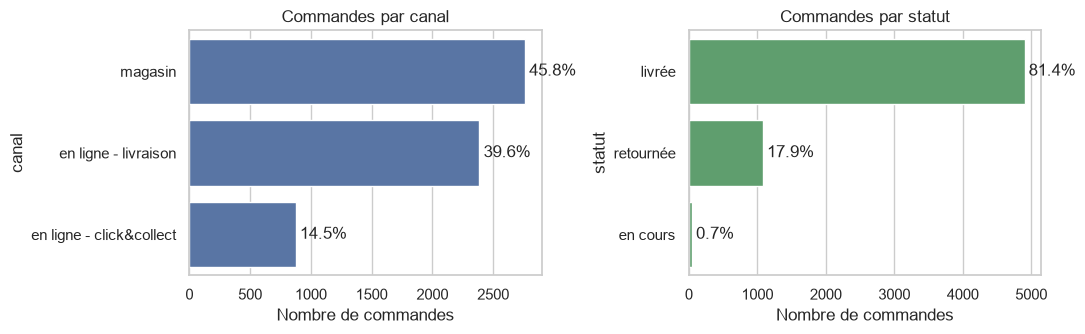

,n,%
canal,,
magasin,2762,45.8
en ligne - livraison,2387,39.6
en ligne - click&collect,875,14.5


,n,%
statut,,
livrée,4901,81.4
retournée,1080,17.9
en cours,43,0.7


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

canal_counts = commandes["canal"].value_counts()
sns.barplot(x=canal_counts.values, y=canal_counts.index, ax=axes[0], color="#4C72B0")
axes[0].set_title("Commandes par canal")
axes[0].set_xlabel("Nombre de commandes")

statut_counts = commandes["statut"].value_counts()
sns.barplot(x=statut_counts.values, y=statut_counts.index, ax=axes[1], color="#55A868")
axes[1].set_title("Commandes par statut")
axes[1].set_xlabel("Nombre de commandes")

# Pourcentage affiché directement sur chaque barre, plutôt que dans un
# tableau à part : plus rapide à lire pour comparer statut et canal.
for ax, counts in [(axes[0], canal_counts), (axes[1], statut_counts)]:
    pourcentages = (counts / len(commandes) * 100).round(1)
    ax.bar_label(ax.containers[0], labels=[f"{p:.1f}%" for p in pourcentages], padding=3)

plt.tight_layout()
plt.show()

display(pd.concat([
    canal_counts.rename("n"), (canal_counts / len(commandes) * 100).round(1).rename("%")
], axis=1))
display(pd.concat([
    statut_counts.rename("n"), (statut_counts / len(commandes) * 100).round(1).rename("%")
], axis=1))

Le canal magasin domine (45,8%), suivi de la livraison à domicile (39,6%)
puis du Click&Collect (14,5%). Côté statut, la très grande majorité des
commandes sont `livrée` (81,4%), une petite fraction est `retournée`
(17,9%), et seule une poignée reste `en cours` (0,7%).


## 3.2 Distribution des montants

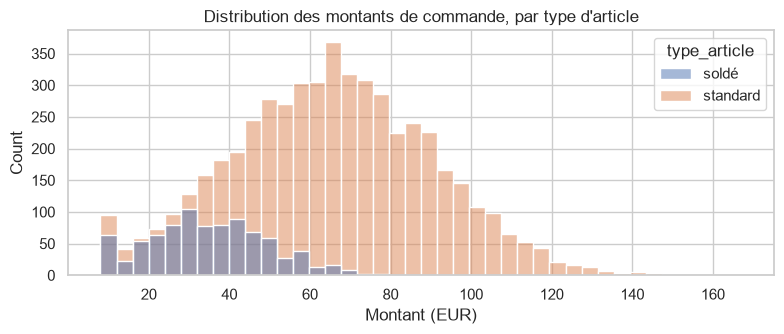

,count,mean,std,min,25%,50%,75%,max
type_article,,,,,,,,
soldé,872.0,35.01,14.76,8.0,24.70,34.61,44.66,84.62
standard,5152.0,65.18,24.96,10.0,48.04,65.06,82.27,167.20


In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.histplot(data=commandes, x="montant", hue="type_article", bins=40, ax=ax, palette=["#4C72B0", "#DD8452"])
ax.set_title("Distribution des montants de commande, par type d'article")
ax.set_xlabel("Montant (EUR)")
plt.tight_layout()
plt.show()

display(commandes.groupby("type_article")["montant"].describe().round(2))

Les deux distributions sont centrées sur des niveaux différents par
construction : les articles standards autour de 65 EUR, les articles soldés
plus bas, autour de 35 EUR. C'est attendu, une remise se lit sur le prix.

## 3.3 Motifs de retour

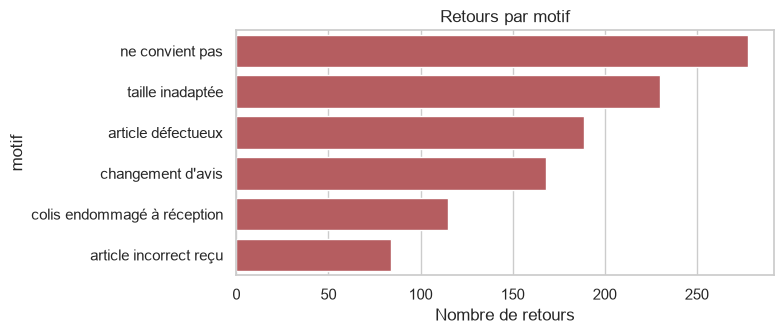

,%
motif,
ne convient pas,25.7
taille inadaptée,21.3
article défectueux,17.5
changement d'avis,15.6
colis endommagé à réception,10.6
article incorrect reçu,7.8


In [6]:
motif_counts = retours["motif"].value_counts()
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.barplot(x=motif_counts.values, y=motif_counts.index, ax=ax, color="#C44E52")
ax.set_title("Retours par motif")
ax.set_xlabel("Nombre de retours")
plt.tight_layout()
plt.show()

display((motif_counts / len(retours) * 100).round(1).rename("%").to_frame())

Les motifs généralistes (taille inadaptée, article ne convenant pas,
changement d'avis) dominent, ce qui est attendu pour un retailer mode. Les
deux motifs réservés aux commandes en ligne (colis endommagé, article
incorrect reçu) restent minoritaires mais non négligeables : ce sont deux
catégories que le guide des commandes en ligne documente spécifiquement, et
qui n'existent pas pour un achat en magasin.

# 4. Analyse bivariée

Les sections précédentes décrivent chaque variable seule. La question
opérationnelle est ailleurs : où est-ce que les choses se dégradent, et
par rapport à quel repère.

## 4.1 Taux de retour en fonction du canal d'achat

type_article,soldé,standard
canal,,
en ligne - click&collect,17.1,15.1
en ligne - livraison,47.0,25.4
magasin,11.8,9.2


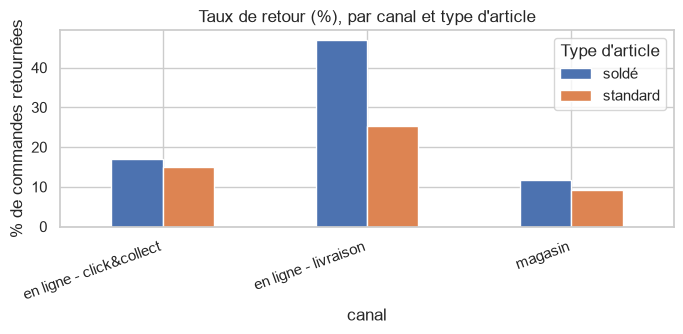

In [7]:
taux_retour = (
    commandes.assign(retourne=(commandes["statut"] == "retournée").astype(int))
    .groupby(["canal", "type_article"])["retourne"]
    .mean()
    .mul(100)
    .round(1)
    .unstack()
)
display(taux_retour)

fig, ax = plt.subplots(figsize=(7, 3.5))
taux_retour.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Taux de retour (%), par canal et type d'article")
ax.set_ylabel("% de commandes retournées")
ax.legend(title="Type d'article")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Le taux de retour n'est pas une fonction simple du canal ou du type
d'article pris séparément : c'est leur combinaison qui crée l'écart. Sur
la livraison à domicile, un article soldé revient près de deux fois plus
souvent qu'un article standard, et nettement plus que le même article
soldé acheté en magasin ou en click&collect. L'explication tient à l'acte
d'achat : une remise en ligne, achetée sans essayage, est plus susceptible
de décevoir à la réception. Le même article, acheté en magasin, a déjà
été essayé avant l'achat.

# 5. Garde-fous et assistant text-to-SQL

L'assistant traduit une question en langage naturel en requête SQL,
l'exécute, puis rédige une réponse claire pour un interlocuteur métier.

Le contrat de sécurité repose sur quatre garde-fous :

1. connexion SQLite en lecture seule 
2. validation de la requête par arbre syntaxique (`sqlglot`), limitée aux
   quatre tables et à un SELECT unique (jointures autorisées entre elles) 
3. plafond de lignes 
4. délai maximum d'exécution


In [8]:
ALLOWED_TABLES = {"magasins", "commandes", "retours", "remboursements"}
MAX_ROWS = 1000
QUERY_TIMEOUT_S = 10

SCHEMA = """
Table `magasins` (un magasin Maison Kurt) :
- magasin_id (INTEGER, clé primaire)
- nom (TEXT)
- ville (TEXT)

Table `commandes` (une commande, en magasin ou en ligne) :
- commande_id (INTEGER, clé primaire)
- magasin_id (INTEGER, clé étrangère vers magasins.magasin_id)
- canal (TEXT) : 'magasin', 'en ligne - livraison' ou 'en ligne - click&collect'
- date_commande (TEXT, format AAAA-MM-JJ)
- type_article (TEXT) : 'standard' ou 'soldé'
- moyen_paiement (TEXT) : 'carte bancaire' ou 'carte cadeau'
- montant (REAL, euros)
- statut (TEXT) : 'en cours', 'livrée' ou 'retournée'
- delai_traitement_jours (INTEGER ou NULL si la commande est encore en cours) : délai réel de livraison
- delai_sla_jours (INTEGER) : délai promis selon le canal
- en_retard (INTEGER 0/1, ou NULL si en cours) : 1 si delai_traitement_jours > delai_sla_jours

Table `retours` (un retour rattaché à une commande livrée) :
- retour_id (INTEGER, clé primaire)
- commande_id (INTEGER, clé étrangère vers commandes.commande_id)
- date_retour (TEXT, format AAAA-MM-JJ)
- motif (TEXT) : 'ne convient pas', 'taille inadaptée', 'article défectueux', "changement d'avis",
  'colis endommagé à réception' ou 'article incorrect reçu' (ces deux derniers uniquement pour les commandes en ligne)
- delai_traitement_jours (INTEGER) : délai de traitement du retour par le magasin
- dans_delai (INTEGER 0/1) : 1 si le retour respecte le délai contractuel (30 jours standard, 14 jours soldé)

Table `remboursements` (un remboursement rattaché à un retour accepté) :
- remboursement_id (INTEGER, clé primaire)
- retour_id (INTEGER, clé étrangère vers retours.retour_id)
- moyen_paiement (TEXT) : 'carte bancaire' ou 'carte cadeau'
- montant (REAL, euros)
- date_remboursement (TEXT, format AAAA-MM-JJ)
- delai_jours (INTEGER) : délai entre le retour et le remboursement
"""

SQL_PROMPT = (
    "Tu es un expert SQL SQLite spécialisé dans l'analyse de données retail.\n"
    "Ta tâche est de transformer la question métier en UNE requête SQL correcte.\n\n"

    "SCHÉMA DE LA BASE :\n"
    "{schema}\n\n"

    "CLÉS ÉTRANGÈRES (seules jointures valides, à respecter strictement) :\n"
    "- magasins.magasin_id = commandes.magasin_id\n"
    "- commandes.commande_id = retours.commande_id\n"
    "- retours.retour_id = remboursements.retour_id\n"
    "- pour relier remboursements à commandes ou à magasins, passer par retours.\n\n"

    "RÈGLES DE VOCABULAIRE :\n"
    "- 'en ligne' désigne le canal de commande, pas le moyen de paiement.\n"
    "- 'carte bancaire' désigne un moyen de paiement, pas un canal de commande.\n"
    "- 'en retard' désigne commandes.en_retard = 1 ; 'hors délai' pour un retour désigne retours.dans_delai = 0.\n"
    "- 'commandes retournées' désigne commandes.statut = 'retournée'.\n"
    "- pour des 'magasins', retourne magasins.nom plutôt que magasins.magasin_id, sauf si l'identifiant est explicitement demandé.\n\n"

    "RÈGLES STRICTES DE SQL :\n"
    "- UNIQUEMENT une requête SELECT, jamais INSERT/UPDATE/DELETE/DROP/ALTER/CREATE/PRAGMA.\n"
    "- une seule instruction, sans point-virgule.\n"
    "- uniquement les tables et colonnes du schéma, jamais sqlite_master.\n"
    "- jointure explicite (JOIN ... ON) si plusieurs tables sont nécessaires.\n"
    "- LIMIT 20 au maximum pour une liste, LIMIT 1 pour 'le plus fréquent'.\n"
    "- réponds avec la requête SQL SEULE, sans explication ni balise Markdown.\n\n"

    "EXEMPLES :\n\n"

    "Question : Quel est le motif de retour le plus fréquent ?\n"
    "SQL : SELECT motif FROM retours GROUP BY motif ORDER BY COUNT(*) DESC LIMIT 1\n\n"

    "Question : Quel est le délai moyen de traitement des retours pour les commandes passées en magasin ?\n"
    "SQL : SELECT AVG(r.delai_traitement_jours) FROM retours r JOIN commandes c ON r.commande_id = c.commande_id WHERE c.canal = 'magasin'\n\n"

    "Question : Combien de remboursements par carte bancaire concernent des commandes soldées ?\n"
    "SQL : SELECT COUNT(*) FROM remboursements rb JOIN retours r ON rb.retour_id = r.retour_id JOIN commandes c ON r.commande_id = c.commande_id WHERE rb.moyen_paiement = 'carte bancaire' AND c.type_article = 'soldé'\n\n"

    "Question : {question}\n"
    "SQL :"
)

NARRATE_PROMPT = (
    "Tu es analyste opérations retail. En 1 à 3 phrases claires,\n"
    "réponds à la question à partir du résultat SQL, pour un interlocuteur métier.\n"
    "N'avance aucun chiffre qui ne figure pas dans le résultat. Si le résultat\n"
    "est partiel, dis-le explicitement plutôt que de généraliser.\n\n"
    "Question : {question}\n"
    "Résultat : {n_lignes} ligne(s){note}\n{result}\n\n"
    "Réponse :"
)


def get_llm(temperature: float = 0.0):
    provider = os.getenv("LLM_PROVIDER", "ollama").lower()
    if provider == "openai":
        from langchain_openai import ChatOpenAI
        return ChatOpenAI(model=os.getenv("OPENAI_MODEL", "gpt-4o-mini"), temperature=temperature)
    from langchain_ollama import ChatOllama
    return ChatOllama(model=os.getenv("OLLAMA_MODEL", "llama3.2"), temperature=temperature)


print("Garde-fous configurés :")
print(f"  ALLOWED_TABLES = {sorted(ALLOWED_TABLES)}")
print(f"  MAX_ROWS = {MAX_ROWS} | QUERY_TIMEOUT_S = {QUERY_TIMEOUT_S}s | DB_PATH = {DB_PATH}")

Garde-fous configurés :
  ALLOWED_TABLES = ['commandes', 'magasins', 'remboursements', 'retours']
  MAX_ROWS = 1000 | QUERY_TIMEOUT_S = 10s | DB_PATH = C:\Users\jboul\Desktop\Dev\Linkdin\demo\retail-operations-rag\data\operations.sqlite


In [9]:
SQL_CONTINUATIONS = {
    "select", "from", "where", "group", "order", "having", "limit", "offset",
    "join", "left", "right", "inner", "outer", "cross", "on", "union",
    "and", "or", "with", "as", "case", "when", "else", "end", "(", ")",
}


def extract_sql(text: str) -> str:
    text = re.sub(r"```(?:sql)?", "", text, flags=re.IGNORECASE).strip("` \n")
    m = re.search(r"(?is)\bselect\b.*", text)
    sql = m.group(0) if m else text
    sql = re.split(r";|```", sql)[0]
    # Une ligne vide n'est PAS une fin de requête : c'est aussi du SQL aéré.
    # On ne coupe que si le bloc suivant ne commence pas par un mot-clé SQL,
    # sinon une requête bien formatée est tronquée en silence et le fragment
    # restant s'exécute sans erreur, en renvoyant un résultat faux.
    blocs = re.split(r"\n\s*\n", sql)
    garde = [blocs[0]]
    for bloc in blocs[1:]:
        premier = bloc.strip().split(None, 1)[0].lower().strip("(,") if bloc.strip() else ""
        if premier in SQL_CONTINUATIONS:
            garde.append(bloc)
        else:
            break
    return "\n".join(garde).strip()


_TABLES_RE = re.compile(r"\b(?:from|join)\s+([a-zA-Z_]\w*)", re.IGNORECASE)
_MOTS_INTERDITS = re.compile(
    r"\b(drop|delete|update|insert|alter|attach|detach|pragma|vacuum|reindex)\b",
    re.IGNORECASE,
)


def tables_referencees(sql: str) -> set:
    return {t.lower() for t in _TABLES_RE.findall(sql)}


def _is_safe_sqlglot(sql: str) -> bool:
    """Validation structurelle : on analyse l'arbre syntaxique, pas le texte.

    Les jointures sont autorisées : c'est la table, pas la jointure, qui est
    le périmètre de sécurité. Chaque table de l'arbre, quel que soit le
    nombre de JOIN, doit appartenir à ALLOWED_TABLES.
    """
    import sqlglot
    from sqlglot import exp

    try:
        instructions = sqlglot.parse(sql, read="sqlite")
    except Exception:
        return False
    if len(instructions) != 1:
        return False
    arbre = instructions[0]
    if not isinstance(arbre, exp.Select):
        return False
    tables = list(arbre.find_all(exp.Table))
    if not tables:
        return False
    if any(t.name.lower() not in ALLOWED_TABLES for t in tables):
        return False
    interdits = (exp.Insert, exp.Update, exp.Delete, exp.Create, exp.Drop, exp.Alter)
    return not any(isinstance(n, interdits) for n in arbre.walk())


def _is_safe_regex(sql: str) -> bool:
    """Repli si sqlglot n'est pas installé. Même contrat, garanties plus faibles.

    Reconnaît aussi les tables introduites par JOIN, mais sans comprendre la
    structure de la requête : une jointure malformée ou une sous-requête
    imbriquée de façon inhabituelle peut lui échapper là où sqlglot la
    vérifierait sur l'arbre syntaxique complet.
    """
    nu = sql.strip()
    if not nu.lower().startswith("select") or ";" in nu:
        return False
    hors_chaines = re.sub(r"'[^']*'", "''", nu)
    if _MOTS_INTERDITS.search(hors_chaines):
        return False
    return tables_referencees(hors_chaines).issubset(ALLOWED_TABLES)


def is_safe(sql: str) -> bool:
    try:
        import sqlglot  # noqa: F401
    except ImportError:
        return _is_safe_regex(sql)
    return _is_safe_sqlglot(sql)

In [10]:
def _connexion_lecture_seule() -> sqlite3.Connection:
    if not DB_PATH.exists():
        raise FileNotFoundError(
            f"Base introuvable : {DB_PATH}. Exécuter d'abord `02_generation_donnees.ipynb`."
        )
    con = sqlite3.connect(f"{DB_PATH.as_uri()}?mode=ro", uri=True)
    limite = time.monotonic() + QUERY_TIMEOUT_S
    con.set_progress_handler(lambda: time.monotonic() > limite, 100_000)
    return con


def run_sql(sql: str):
    con = _connexion_lecture_seule()
    try:
        lecteur = pd.read_sql(sql, con, chunksize=MAX_ROWS)
        df = next(lecteur, pd.DataFrame())
        tronque = next(lecteur, None) is not None
    finally:
        con.close()
    return df, tronque


def generate_sql(question: str, max_retries: int = 1):
    """
    Génère, valide et exécute le SQL correspondant à une question.

    Cette fonction est utilisée pour l'évaluation Text-to-SQL.
    Elle ne génère PAS de réponse en langage naturel.
    """

    from langchain_core.output_parsers import StrOutputParser
    from langchain_core.prompts import ChatPromptTemplate

    llm = get_llm()
    sql_chain = (
        ChatPromptTemplate.from_template(SQL_PROMPT)
        | llm
        | StrOutputParser()
    )

    error, sql = None, ""

    for _ in range(max_retries + 1):

        # Si une tentative précédente a échoué,
        # on demande au modèle de corriger son SQL.
        q = (
            question
            if error is None
            else f"{question}\n"
                 f"(La requête précédente a échoué : {error}. "
                 f"Corrige-la.)"
        )

        sql = extract_sql(
            sql_chain.invoke({
                "schema": SCHEMA,
                "question": q
            })
        )

        # Garde-fou de sécurité
        if not is_safe(sql):
            return (
                "Requête refusée : seules les tables magasins, commandes, "
                "retours et remboursements sont autorisées.",
                sql,
                None,
                False
            )

        try:
            # Exécution de la requête
            df, tronque = run_sql(sql)

            return (
                None,
                sql,
                df,
                tronque
            )

        except Exception as exc:
            error = str(exc)

    # Toutes les tentatives ont échoué
    return (
        f"Échec de la génération SQL : {error}",
        sql,
        None,
        False
    )


def ask(question: str, max_retries: int = 1, verbose: bool = True):
    """
    Fonction destinée à la démonstration utilisateur.

    Elle :
    1. génère le SQL
    2. vérifie la sécurité
    3. exécute le SQL
    4. génère une réponse naturelle à partir du résultat

    La génération de la réponse naturelle n'est donc utilisée
    que pour le chatbot/démonstrateur, pas pour le benchmark.
    """

    from langchain_core.output_parsers import StrOutputParser
    from langchain_core.prompts import ChatPromptTemplate

    # =========================================================
    # 1. Génération + validation + exécution du SQL
    # =========================================================

    error, sql, df, tronque = generate_sql(
        question,
        max_retries=max_retries
    )

    # Requête refusée ou erreur d'exécution
    if df is None:

        if verbose and error:
            print(f"\n{error}")

        return (
            error,
            sql,
            None
        )

    # =========================================================
    # 2. Préparation du résultat pour la réponse naturelle
    # =========================================================

    llm = get_llm()

    apercu = df.head(20)

    note = ""

    if tronque:
        note = (
            f" (plafond de lecture de {MAX_ROWS} lignes atteint, "
            f"le total réel est supérieur)"
        )

    if len(df) > len(apercu):
        note += (
            f" ; seules les {len(apercu)} premières sont "
            f"reproduites ci-dessous"
        )

    # =========================================================
    # 3. Génération de la réponse naturelle
    # =========================================================

    narrate = (
        ChatPromptTemplate.from_template(NARRATE_PROMPT)
        | llm
        | StrOutputParser()
    )

    answer = narrate.invoke({
        "question": question,
        "n_lignes": len(df),
        "note": note,
        "result": apercu.to_string(index=False),
    })

    # =========================================================
    # 4. Affichage pour la démonstration
    # =========================================================

    if verbose:
        print("\nSQL généré :\n ", sql)
        print(f"\nRésultat : {len(df)} ligne(s){note}")
        print(df.head(10).to_string(index=False))

    return answer, sql, df

# 6. Tests des garde-fous

Ne nécessite ni base de données, ni LLM : on teste uniquement les fonctions
pures `is_safe` et `extract_sql`, sur des requêtes à autoriser (jointures
comprises) et des requêtes à bloquer.

In [11]:
AUTORISEES = [
    "SELECT COUNT(*) FROM commandes WHERE canal = 'magasin'",
    "SELECT motif, COUNT(*) FROM retours GROUP BY motif ORDER BY 2 DESC LIMIT 5",
    "select statut, avg(montant) from commandes group by statut",
    # Jointure entre deux tables de la liste blanche : c'est précisément ce
    # que ce projet autorise.
    """SELECT m.nom, AVG(c.en_retard) FROM commandes c
       JOIN magasins m ON c.magasin_id = m.magasin_id
       WHERE c.canal = 'en ligne - livraison' GROUP BY m.nom""",
    # Jointure à trois tables.
    """SELECT r.motif, AVG(rb.delai_jours) FROM retours r
       JOIN commandes c ON r.commande_id = c.commande_id
       JOIN remboursements rb ON rb.retour_id = r.retour_id
       GROUP BY r.motif""",
    # Une chaîne littérale contenant un mot-clé interdit ne doit pas
    # déclencher la liste noire : c'est de la donnée, pas une instruction.
    "SELECT * FROM commandes WHERE motif LIKE '%update %' LIMIT 10",
    # Sous-requête : seule la table réelle compte, la table dérivée n'est
    # pas un nom à autoriser.
    "SELECT AVG(m) FROM (SELECT SUM(montant) m FROM commandes GROUP BY magasin_id)",
]

REFUSEES = [
    "DROP TABLE commandes",
    "DELETE FROM retours",
    "UPDATE commandes SET montant = 0",
    "INSERT INTO commandes VALUES (1)",
    "SELECT 1 FROM commandes; DROP TABLE commandes",
    "SELECT name, sql FROM sqlite_master",
    "SELECT * FROM sqlite_sequence",
    "SELECT c.montant FROM commandes c JOIN sqlite_master s ON 1=1",
    "ATTACH DATABASE 'autre.sqlite' AS x",
    "SELECT * FROM commandes WHERE 1=1 ATTACH DATABASE 'x' AS y",
    "WITH t AS (SELECT 1 FROM commandes) SELECT * FROM t",
]


def _verifier(valideur, nom: str) -> None:
    for sql in AUTORISEES:
        assert valideur(sql), f"[{nom}] faux refus : {sql}"
    for sql in REFUSEES:
        assert not valideur(sql), f"[{nom}] NON BLOQUÉ : {sql}"


_verifier(is_safe, "actif")
_verifier(_is_safe_sqlglot, "sqlglot")
_verifier(_is_safe_regex, "regex")

# extract_sql : une ligne vide dans une requête formatée n'est pas une fin
# de requête, mais une explication ajoutée après doit disparaître.
_aere = "SELECT motif, COUNT(*)\nFROM retours\n\nGROUP BY motif\n\nORDER BY 2 DESC\nLIMIT 5"
assert "ORDER BY" in extract_sql(_aere).upper() and "LIMIT" in extract_sql(_aere).upper()

_bavard = "SELECT COUNT(*) FROM commandes\n\nCette requête compte le nombre total de commandes."
assert extract_sql(_bavard) == "SELECT COUNT(*) FROM commandes"

assert extract_sql("```sql\nSELECT 1 FROM commandes\n```") == "SELECT 1 FROM commandes"

print(f"Garde-fous vérifiés : {len(AUTORISEES)} requêtes autorisées, {len(REFUSEES)} requêtes bloquées, "
      f"sur les deux validateurs (arbre syntaxique et repli par expressions régulières).")

Garde-fous vérifiés : 7 requêtes autorisées, 11 requêtes bloquées, sur les deux validateurs (arbre syntaxique et repli par expressions régulières).


# 7. Démonstration

Deux questions : un comptage simple, et une question qui exige une
jointure entre plusieurs tables. Le notebook affiche le SQL généré et le
résultat afin de rendre le comportement observable, pas seulement la
réponse rédigée.

In [12]:
answer, sql, df = ask("Combien de commandes ont été retournées au total ?")
print("\nRÉPONSE :", answer)


SQL généré :
  SELECT COUNT(*) FROM retours

Résultat : 1 ligne(s)
 COUNT(*)
     1080

RÉPONSE : Il y a 1 commande qui a été retournée au total.


In [13]:
answer, sql, df = ask("Quel est le délai moyen entre le retour et le remboursement pour les commandes en ligne ?")
print("\nRÉPONSE :", answer)


SQL généré :
  SELECT AVG(rb.delai_jours) FROM remboursements rb JOIN retours r ON rb.retour_id = r.retour_id JOIN commandes c ON r.commande_id = c.commande_id WHERE c.canal = 'en ligne - livraison'

Résultat : 1 ligne(s)
 AVG(rb.delai_jours)
            3.205714

RÉPONSE : Le délai moyen entre le retour et le remboursement pour les commandes en ligne est de 3 jours.


# 8. Évaluation du text-to-SQL

La démonstration seule ne mesure rien. On utilise un jeu de 17 questions
métier, chacune associée à un SQL de référence écrit à la main et vérifié
directement sur la base. Le jeu est partagé entre questions à une seule
table et questions à jointure (2 ou 3 tables), pour pouvoir isoler l'effet
de la jointure sur la fiabilité. C'était la question de départ de ce
notebook.

Pour chaque question :
1. le modèle génère un SQL (`generate_sql`, sans narration : la comparaison
   porte sur le résultat brut, pas sur une phrase rédigée) ;
2. le SQL généré est exécuté s'il passe le garde-fou ;
3. le SQL de référence est exécuté sur la même base ;
4. les deux résultats sont comparés en entier (`resultats_egaux`) : même
   nombre de lignes et de colonnes, valeurs numériques égales à 0,01 près,
   valeurs texte comparées après normalisation (espaces, casse). Une
   première version de cette comparaison ne regardait que la première
   cellule du résultat, ce qui pénalisait à tort les questions renvoyant
   plusieurs lignes (un classement de magasins, par exemple).

L'accuracy mesurée ici est une **execution accuracy** : elle compare des
résultats, pas des requêtes. Deux requêtes syntaxiquement différentes qui
renvoient le même résultat comptent comme un succès.


In [14]:
from questions import EVAL_SET

print(
    f"{len(EVAL_SET)} questions, "
    f"dont {sum(j for _, _, j in EVAL_SET)} avec jointure."
)


17 questions, dont 6 avec jointure.


## Test sur 5 questions

Avant de lancer l'évaluation complète (17 questions, plusieurs minutes),
un test rapide sur 5 questions représentatives, 3 sans jointure et 2 avec,
vérifie que le pipeline tient bout en bout (génération, garde-fou,
exécution) avant d'investir le temps de la passe complète.

In [15]:
echantillon = [EVAL_SET[i] for i in (0, 2, 5, 11, 14)]

for question, sql_ref, avec_jointure in echantillon:
    ref_df, _ = run_sql(sql_ref)
    message, sql_genere, gen_df, tronque = generate_sql(question, max_retries=1)

    print("\n" + "=" * 70)
    print(f"QUESTION ({'JOIN' if avec_jointure else 'sans jointure'})")
    print(question)
    print("\nSQL GÉNÉRÉ")
    print(sql_genere)
    if gen_df is None:
        print("\nÉCHEC :", message)
    else:
        print(f"\nRÉSULTAT ({len(gen_df)} ligne(s))")
        print(gen_df.head(5).to_string(index=False))


QUESTION (sans jointure)
Combien de commandes ont le statut livrée ?

SQL GÉNÉRÉ
SELECT COUNT(*) FROM commandes WHERE statut = 'livrée'

RÉSULTAT (1 ligne(s))
 COUNT(*)
     4901



QUESTION (sans jointure)
Quel est le montant total des remboursements effectués par carte cadeau ?

SQL GÉNÉRÉ
SELECT SUM(montant) FROM remboursements WHERE moyen_paiement = 'carte cadeau'

RÉSULTAT (1 ligne(s))
 SUM(montant)
     12352.18



QUESTION (sans jointure)
Quel est le motif de retour le plus fréquent ?

SQL GÉNÉRÉ
SELECT motif FROM retours GROUP BY motif ORDER BY COUNT(*) DESC LIMIT 1

RÉSULTAT (1 ligne(s))
          motif
ne convient pas



QUESTION (JOIN)
Combien de commandes retournées le magasin de Marseille a-t-il enregistrées ?

SQL GÉNÉRÉ
SELECT COUNT(*) FROM retours r JOIN commandes c ON r.commande_id = c.commande_id WHERE c.canal = 'magasin' AND c.statut = 'retournée' AND r.date_retour LIKE 'AAAA-MM-JJ' AND r.motif IN ('ne convient pas', 'taille inadaptée', 'article défectueux', "changement d'avis", 'colis endommagé à réception') AND r.date_retour >= '2022-01-01' AND r.date_retour <= '2022-12-31' AND c.nom = 'Maison Kurt'

ÉCHEC : Échec de la génération SQL : Execution failed on sql 'SELECT COUNT(*) FROM retours r JOIN commandes c ON r.commande_id = c.commande_id WHERE c.canal = 'magasin' AND c.statut = 'retournée' AND r.date_retour LIKE 'AAAA-MM-JJ' AND r.motif IN ('ne convient pas', 'taille inadaptée', 'article défectueux', "changement d'avis", 'colis endommagé à réception') AND r.date_retour >= '2022-01-01' AND r.date_retour <= '2022-12-31' AND c.nom = 'Maison Kurt'': no such column: c.nom



QUESTION (JOIN)
Quel est le montant moyen remboursé pour le motif article défectueux ?

SQL GÉNÉRÉ
SELECT AVG(montant) FROM remboursements rb JOIN retours r ON rb.retour_id = r.retour_id WHERE r.motif = 'article défectueux'

RÉSULTAT (1 ligne(s))
 AVG(montant)
    58.947935


In [16]:
def resultats_egaux(ref_df, gen_df):
    """
    Compare les résultats SQL générés et de référence.

    La comparaison porte sur :
    - le nombre de lignes ;
    - le nombre de colonnes ;
    - les valeurs retournées.

    Les noms de colonnes ne sont PAS considérés comme
    significatifs, car deux requêtes SQL équivalentes peuvent
    utiliser des alias différents ou aucun alias.
    """

    if ref_df is None or gen_df is None:
        return False

    # Même nombre de lignes et de colonnes
    if ref_df.shape != gen_df.shape:
        return False

    # Réinitialiser les index
    ref = ref_df.reset_index(drop=True).copy()
    gen = gen_df.reset_index(drop=True).copy()

    # Comparaison colonne par colonne
    for i in range(ref.shape[1]):

        ref_col = ref.iloc[:, i]
        gen_col = gen.iloc[:, i]

        # Colonnes numériques
        if (
            pd.api.types.is_numeric_dtype(ref_col)
            and pd.api.types.is_numeric_dtype(gen_col)
        ):
            if not np.allclose(
                ref_col.astype(float),
                gen_col.astype(float),
                rtol=0,
                atol=0.01,
                equal_nan=True
            ):
                return False

        # Colonnes texte / autres
        else:
            ref_values = (
                ref_col
                .fillna("")
                .astype(str)
                .str.strip()
                .str.lower()
            )

            gen_values = (
                gen_col
                .fillna("")
                .astype(str)
                .str.strip()
                .str.lower()
            )

            if not ref_values.equals(gen_values):
                return False

    return True


resultats = []

for question, sql_ref, avec_jointure in EVAL_SET:

    # =========================================================
    # 1. Exécution de la requête de référence
    # =========================================================
    ref_df, erreur_ref = run_sql(sql_ref)

    if ref_df is None:
        resultats.append({
            "question": question,
            "jointure": avec_jointure,
            "reussi": False,
            "statut": "erreur_reference",
            "valeur_ref": None,
            "valeur_gen": None,
            "sql_genere": None,
        })

        print(
            f"[{'ERREUR_REFERENCE':16s}] "
            f"{'JOIN' if avec_jointure else '    '}  "
            f"{question[:60]}"
        )

        continue

    # =========================================================
    # 2. Génération + exécution du SQL par le système
    # =========================================================
    message, sql_genere, df_genere, tronque = generate_sql(
    question,
    max_retries=1
)

    # =========================================================
    # 3. Classification du résultat
    # =========================================================

    # Requête bloquée par le garde-fou
    if (
        df_genere is None
        and message.startswith("Requête refusée")
    ):
        statut_brut = "refus_garde_fou"

    # SQL généré mais impossible à exécuter
    elif df_genere is None:
        statut_brut = "echec_execution"

    # SQL exécuté : comparaison du résultat COMPLET
    else:
        if resultats_egaux(ref_df, df_genere):
            statut_brut = "ok"
        else:
            statut_brut = "ecart"

    # =========================================================
    # 4. Valeurs affichées à titre informatif
    # =========================================================

    # Première cellule de la référence :
    # conservée uniquement pour faciliter la lecture
    valeur_ref = (
        ref_df.iloc[0, 0]
        if len(ref_df) and len(ref_df.columns)
        else None
    )

    # Première cellule du résultat généré :
    # conservée uniquement pour faciliter la lecture
    valeur_gen = (
        df_genere.iloc[0, 0]
        if (
            df_genere is not None
            and len(df_genere)
            and len(df_genere.columns)
        )
        else None
    )

    # =========================================================
    # 5. Succès / échec
    # =========================================================
    reussi = statut_brut == "ok"

    # =========================================================
    # 6. Stockage des résultats
    # =========================================================
    resultats.append({
        "question": question,
        "jointure": avec_jointure,
        "reussi": reussi,
        "statut": statut_brut,

        # Ces deux colonnes servent uniquement
        # à faciliter l'inspection des résultats.
        # Elles ne déterminent PLUS l'exactitude.
        "valeur_ref": valeur_ref,
        "valeur_gen": valeur_gen,

        "sql_genere": sql_genere,

        # Informations supplémentaires utiles
        "nb_lignes_ref": len(ref_df),
        "nb_lignes_gen": (
            len(df_genere)
            if df_genere is not None
            else None
        ),
    })

    print(
        f"[{statut_brut.upper():16s}] "
        f"{'JOIN' if avec_jointure else '    '}  "
        f"{question[:60]}"
    )


# =============================================================
# 7. DataFrame final d'évaluation
# =============================================================
eval_df = pd.DataFrame(resultats)

[OK              ]       Combien de commandes ont le statut livrée ?


[OK              ]       Combien de retours ont été enregistrés au total ?


[OK              ]       Quel est le montant total des remboursements effectués par c


[OK              ]       Quel est le délai moyen de remboursement pour les paiements 


[OK              ]       Combien de commandes ont été passées via le canal en ligne c


...

[OK              ] JOIN  Quel est le délai moyen de traitement des retours pour les c


[ECART           ] JOIN  Quels sont les 5 magasins avec le montant total de commandes


[ECHEC_EXECUTION ] JOIN  Quel est le montant moyen remboursé pour le motif article dé


[ECART           ] JOIN  Quel est le délai moyen entre le retour et le remboursement 


[OK              ] JOIN  Combien de remboursements par carte bancaire concernent des 


In [17]:
display(
    eval_df[
        eval_df["statut"].isin(["ecart", "echec_execution"])
    ][
        [
            "question",
            "statut",
            "sql_genere",
            "valeur_ref",
            "valeur_gen",
            "nb_lignes_ref",
            "nb_lignes_gen",
        ]
    ]
)

,question,statut,sql_genere,valeur_ref,valeur_gen,nb_lignes_ref,nb_lignes_gen
10,Quel pourcentage des commandes en ligne - livr...,ecart,SELECT COUNT(CASE WHEN c.canal = 'en ligne - l...,24.1,9,1,1.0
11,Combien de commandes retournées le magasin de ...,echec_execution,SELECT COUNT(*) FROM retours r JOIN commandes ...,130,None,1,NaN
13,Quels sont les 5 magasins avec le montant tota...,ecart,"SELECT magasin_id, SUM(montant) FROM commandes...",Maison Kurt Lille Centre,2,5,5.0
14,Quel est le montant moyen remboursé pour le mo...,echec_execution,SELECT AVG(r.montant) FROM retours r JOIN remb...,58.95,None,1,NaN
15,Quel est le délai moyen entre le retour et le ...,ecart,SELECT AVG(rb.delai_jours) FROM remboursements...,3.23,3.205714,1,1.0


In [18]:
# Afficher les résultats complets pour la question du Top 5

question_top5 = "Quels sont les 5 magasins avec le montant total de commandes le plus élevé ?"

for question, sql_ref, avec_jointure in EVAL_SET:
    if question == question_top5:

        ref_df, _ = run_sql(sql_ref)

        message, sql_genere, gen_df, tronque = generate_sql(
            question,
            max_retries=1
        )

        print("=== SQL DE RÉFÉRENCE ===")
        print(sql_ref)

        print("\n=== RÉSULTAT DE RÉFÉRENCE ===")
        display(ref_df)

        print("\n=== SQL GÉNÉRÉ ===")
        print(sql_genere)

        print("\n=== RÉSULTAT GÉNÉRÉ ===")
        display(gen_df)

=== SQL DE RÉFÉRENCE ===
SELECT m.nom FROM commandes c JOIN magasins m ON c.magasin_id = m.magasin_id
        GROUP BY m.nom ORDER BY SUM(c.montant) DESC LIMIT 5

=== RÉSULTAT DE RÉFÉRENCE ===


,nom
0,Maison Kurt Lille Centre
1,Maison Kurt Strasbourg Centre
2,Maison Kurt Bordeaux Chartrons
3,Maison Kurt Lyon Part-Dieu
4,Maison Kurt Nantes Centre



=== SQL GÉNÉRÉ ===
SELECT magasin_id, SUM(montant) FROM commandes WHERE canal = 'magasin' GROUP BY magasin_id ORDER BY SUM(montant) DESC LIMIT 5

=== RÉSULTAT GÉNÉRÉ ===


,magasin_id,SUM(montant)
0,2,22325.92
1,5,22233.71
2,4,22220.83
3,1,21289.84
4,8,20841.47


In [19]:
# =========================================================
# Synthèse de l'évaluation Text-to-SQL
# =========================================================

n = len(eval_df)
n_ok = eval_df["reussi"].sum()

# Accuracy globale
print(
    f"Execution accuracy globale : "
    f"{n_ok}/{n} ({n_ok/n:.1%})\n"
)

# Accuracy selon la présence d'une jointure
par_type = (
    eval_df
    .groupby("jointure")["reussi"]
    .agg(["sum", "count"])
)

par_type["taux"] = (
    par_type["sum"] / par_type["count"] * 100
).round(1)

par_type.index = par_type.index.map({
    False: "sans jointure",
    True: "avec jointure"
})

print("Performance selon la présence d'une jointure :")

display(
    par_type.rename(
        columns={
            "sum": "reussies",
            "count": "total",
            "taux": "% réussi"
        }
    )
)

# Répartition des statuts
print("\nRépartition des résultats :")

statuts = (
    eval_df
    .groupby(["jointure", "statut"])
    .size()
    .rename("n")
    .to_frame()
)

display(statuts)

# Résumé des erreurs
print("\nRésumé :")

for statut in ["ecart", "echec_execution", "refus_garde_fou"]:
    nb = (eval_df["statut"] == statut).sum()
    if nb:
        print(f"  {statut} : {nb}")

Execution accuracy globale : 12/17 (70.6%)

Performance selon la présence d'une jointure :


,reussies,total,% réussi
jointure,,,
sans jointure,10,11,90.9
avec jointure,2,6,33.3



Répartition des résultats :


n
jointure statut             
False    ecart             1
         ok               10
True     ecart             2
         echec_execution   2
         ok                2


Résumé :
  ecart : 3
  echec_execution : 2


**[La cellule ci-dessus liste les échecs réels de cette exécution ; le
texte qui suit est écrit après avoir lu ce tableau, pas avant.]**

# 9. Synthèse et limites

Ce notebook est une copie de `03_text_to_sql_operations.ipynb` avec une
seule différence : le `SQL_PROMPT` de la section 5 est la version courte
(2374 caractères, contre 5483 dans l'original), celle brièvement utilisée
dans `app_sql.py` pour réduire le temps de réponse. Le but n'est pas
d'évaluer l'assistant en général, c'est mesuré ailleurs, mais de chiffrer
ce que coûte cette réduction de prompt.

**Ce que la comparaison montre.** Le chiffre à lire est dans la cellule
de la section 8. Sans jointure, l'accuracy tient : 90,9%, au niveau des
deux runs du prompt long (90,9% et 81,8%). Avec jointure, elle s'effondre
à 33,3% (2/6), contre 83,3% les deux fois avec le prompt long. La
différence entre les deux prompts porte presque uniquement sur les
sections retirées : le chemin détaillé des jointures
("CHEMIN DES JOINTURES") et la liste des colonnes par table
("RÈGLES MÉTIER IMPORTANTES"). Ce n'était donc pas du remplissage : sur
ce modèle de 3B, ce sont ces sections qui portent la capacité à enchaîner
plusieurs jointures correctement. Le raccourcissement fait gagner du
temps de réponse, mais au prix quasi exclusif de la fiabilité sur les
questions à jointure, pas d'un coût réparti sur l'ensemble des questions.

**Limitations.**

Les données sont générées, pas mesurées. Les distributions imitent des
règles écrites dans les guides et injectent un signal volontaire
(combinaison canal/type à fort taux de retour) ; elles ne représentent
aucune commande réelle de Maison Kurt, qui est une enseigne fictive.

Le jeu d'évaluation compte 17 questions, dont seulement 6 à jointure.
L'écart mesuré ici (90,9% contre 33,3%, soit 4 échecs sur 6) est net,
mais 6 questions restent un petit échantillon : un seul cas de plus ou de
moins déplace le taux de 17 points.

Le garde-fou garantit qu'aucune requête écrite ou hors périmètre ne
s'exécute ; il ne garantit pas que la requête autorisée réponde à la
bonne question. C'est précisément ce que l'évaluation mesure séparément,
et les deux ne doivent pas être confondus : un système peut être
entièrement sûr et se tromper de réponse. C'est le cas de tous les
échecs mesurés en section 8, où aucun n'est un refus du garde-fou.

La narration en langage naturel (fonction `ask`, section 7) n'est pas
couverte par l'évaluation, qui compare des résultats bruts. Elle peut se
tromper même quand le SQL est correct : dans la démonstration de la
section 7, la réponse rédigée annonce "1 commande" alors que le résultat
SQL affiché juste au-dessus vaut 1080, exactement comme dans le notebook
au prompt long. Cette limite vient de `NARRATE_PROMPT`, identique dans
les deux notebooks, pas du `SQL_PROMPT` comparé ici.

Le modèle utilisé (llama3.2, 3B, local) est un choix de démonstration,
retenu pour sa gratuité et sa disponibilité hors-ligne, pas pour ses
performances. Un modèle plus grand tolérerait sans doute mieux un prompt
court ; ce n'est pas testé ici.